In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_json('Sarcasm_Headlines_Dataset.json', lines=True)
df.head()

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0


In [6]:
df.shape

(26709, 3)

In [7]:
df.dtypes

,0
article_link,object
headline,object
is_sarcastic,int64


In [8]:
df.isnull().sum()

,0
article_link,0
headline,0
is_sarcastic,0


In [9]:
df['is_sarcastic'].value_counts()

,count
is_sarcastic,
0,14985
1,11724


In [10]:
df['headline_length'] = df['headline'].apply(len)

df[['headline', 'headline_length']].head()

,headline,headline_length
0,former versace store clerk sues over secret 'b...,78
1,the 'roseanne' revival catches up to our thorn...,84
2,mom starting to fear son's web series closest ...,79
3,"boehner just wants wife to listen, not come up...",84
4,j.k. rowling wishes snape happy birthday in th...,64


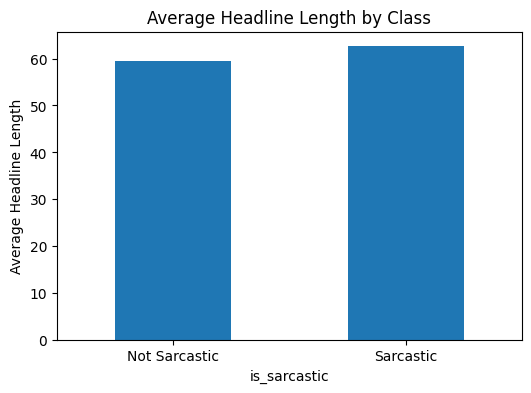

In [11]:
avg_length = df.groupby('is_sarcastic')['headline_length'].mean()

plt.figure(figsize=(6,4))
avg_length.plot(kind='bar')
plt.xticks([0,1], ['Not Sarcastic', 'Sarcastic'], rotation=0)
plt.ylabel('Average Headline Length')
plt.title('Average Headline Length by Class')
plt.show()

In [12]:
df['exclamation_count'] = df['headline'].str.count('!')

df[['headline', 'exclamation_count']].head()

,headline,exclamation_count
0,former versace store clerk sues over secret 'b...,0
1,the 'roseanne' revival catches up to our thorn...,0
2,mom starting to fear son's web series closest ...,0
3,"boehner just wants wife to listen, not come up...",0
4,j.k. rowling wishes snape happy birthday in th...,0


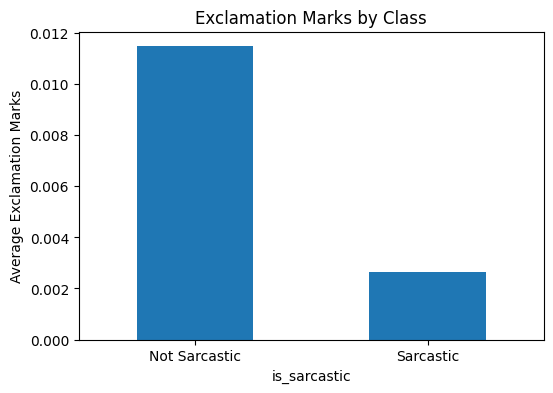

In [13]:
avg_exclaim = df.groupby('is_sarcastic')['exclamation_count'].mean()

plt.figure(figsize=(6,4))
avg_exclaim.plot(kind='bar')
plt.xticks([0,1], ['Not Sarcastic', 'Sarcastic'], rotation=0)
plt.ylabel('Average Exclamation Marks')
plt.title('Exclamation Marks by Class')
plt.show()

In [14]:
sarcastic_text = ' '.join(df[df['is_sarcastic'] == 1]['headline']).lower()
normal_text = ' '.join(df[df['is_sarcastic'] == 0]['headline']).lower()

from collections import Counter

sarcastic_words = Counter(sarcastic_text.split()).most_common(10)
normal_words = Counter(normal_text.split()).most_common(10)

print('Top words in sarcastic headlines:')
print(sarcastic_words)

print()

print('Top words in non-sarcastic headlines:')
print(normal_words)

Top words in sarcastic headlines:
[('to', 4141), ('of', 3131), ('in', 1753), ('for', 1416), ('on', 1053), ('man', 1021), ('with', 854), ('new', 821), ('the', 584), ('by', 580)]

Top words in non-sarcastic headlines:
[('the', 4593), ('to', 4065), ('of', 2462), ('a', 2443), ('in', 2417), ('for', 1881), ('and', 1631), ('is', 1494), ('on', 1318), ('trump', 957)]


The sarcastic and non-sarcastic headlines have differences in punctuation usage and length of headline.sarcastic headlines often use unusual wording whereas non-sarcastic headlines are more direct.If a simple keyword based rule is used it can catch some of the sarcastic headlines but it will srill miss many others as it depends entirely on context and the words used together.So a simple rule is not reliable to detect the sarcasm accurately.